In [1]:
import os
import sys
import re
from matplotlib import pyplot as plt
from coffea.util import load
from omegaconf import OmegaConf
import numpy as np
from pocket_coffea.utils.plot_utils import PlotManager
import awkward as ak


In [2]:
input_dir_data="/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/data_parkingHH_spanet_2023_postBPix"
input_dir_data_old="/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/ggF_vbf_ZZ_ZH_data_parkingHH_old_spanet_bkg_rwg_2023_postBPix"
input_dir_data_dhh="/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/ggF_vbf_ZZ_ZH_data_parkingHH_dhh_bkg_rwg_2023_postBPix"
input_dir_mc="/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/ggF_vbf_ZZ_ZH_spanet_2023_postBPix"
filename = "output_total.coffea"
year="2023_postBPix"

In [3]:
data_c = load(os.path.join(input_dir_data, filename))
mc_c = load(os.path.join(input_dir_mc, filename))
data_c_old = load(os.path.join(input_dir_data_old, filename))
data_c_dhh = load(os.path.join(input_dir_data_dhh, filename))

samples = list(data_c['columns'].keys()) + list(mc_c['columns'].keys())
samples_data = list(data_c['columns'].keys())
samples_mc = list(mc_c['columns'].keys())

samples_data_old = [x for x in list(data_c_old['columns'].keys()) if "DATA" in x]
samples_mc_old = [x for x in list(data_c_old['columns'].keys()) if "DATA" not in x]

samples_data_dhh = [x for x in list(data_c_dhh['columns'].keys()) if "DATA" in x]
samples_mc_dhh = [x for x in list(data_c_dhh['columns'].keys()) if "DATA" not in x]

regions = ['4b_region', '4b_control_region', '4b_signal_region']

variables_data = list(data_c['columns']['DATA_ParkingHH']['DATA_ParkingHH_2023_postBPix_EraDv1']['4b_region']['nominal'].keys())
variables_data_old = list(data_c_dhh['columns'][samples_data_dhh[0]]['DATA_ParkingHH_2023_postBPix_EraDv2']['4b_region']['nominal'].keys())
variables_mc = list(mc_c['columns']['GluGlutoHHto4B_kl-0p00_kt-1p00_c2-0p00']['GluGlutoHHto4B_kl-0p00_kt-1p00_c2-0p00_2023_postBPix']['4b_region']['nominal'].keys())
variables_mc_old = list(data_c_dhh['columns']['GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00']['GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00_2023_postBPix']['4b_signal_region']['nominal'].keys())

In [4]:
list(data_c['columns']['DATA_ParkingHH']['DATA_ParkingHH_2023_postBPix_EraDv1'].keys())

['4b_region',
 '4b_control_region',
 '4b_signal_region',
 '2b_control_region_preW',
 '2b_signal_region_preW',
 'vbf_best_candidates_6_jets_4b_region',
 'vbf_best_candidates_6_jets_nokincut_4b_region']

In [5]:
events = {}
events["data"] = {}
for region in regions:
    events["data"][region] = {}
    for variable in variables_data:
        events["data"][region][variable] = 0
        var = []
        for sample in samples_data:
            subsamples = list(data_c['columns'][sample].keys())
            for subsample in subsamples:
                var.append(data_c['columns'][sample][subsample][region]['nominal'][variable].value)
        events["data"][region][variable] = ak.concatenate(var)

In [6]:
events['mc'] = {}

sum_gen_weights = {}

for sample in samples_mc:
    events["mc"][sample] = {}
    subsamples = list(mc_c['columns'][sample].keys())
    for subsample in subsamples:
        sum_gen_weights[subsample] = mc_c['sum_genweights'][subsample]
        events["mc"][sample][subsample] = {}
        for region in regions:
            events["mc"][sample][subsample][region] = {}
            for variable in variables_mc:
                events["mc"][sample][subsample][region][variable] = mc_c['columns'][sample][subsample][region]['nominal'][variable].value

In [7]:
variables_mc

['weight',
 'events_sigma_over_higgs1_reco_mass',
 'events_Delta_pairing_probabilities',
 'events_dR_max',
 'events_Padded_Arctanh_Delta_pairing_probabilities',
 'events_dR_min',
 'events_sigma_over_higgs2_reco_mass',
 'events_era',
 'events_Arctanh_Delta_pairing_probabilities',
 'events_HT',
 'events_year',
 'events_Binned_Arctanh_Delta_pairing_probabilities',
 'HH_dPhi',
 'HH_phi',
 'HH_eta',
 'HH_Costhetastar_CS',
 'HH_mass',
 'HH_pt',
 'HH_dR',
 'HH_dEta',
 'HiggsLeading_dPhi',
 'HiggsLeading_phi',
 'HiggsLeading_eta',
 'HiggsLeading_pt',
 'HiggsLeading_mass',
 'HiggsLeading_helicityCosTheta',
 'HiggsLeading_dR',
 'HiggsLeading_dEta',
 'HiggsSubLeading_dPhi',
 'HiggsSubLeading_phi',
 'HiggsSubLeading_eta',
 'HiggsSubLeading_pt',
 'HiggsSubLeading_mass',
 'HiggsSubLeading_helicityCosTheta',
 'HiggsSubLeading_dR',
 'HiggsSubLeading_dEta',
 'JetGoodFromHiggsOrdered_N',
 'JetGoodFromHiggsOrdered_pt',
 'JetGoodFromHiggsOrdered_mass',
 'JetGoodFromHiggsOrdered_phi',
 'JetGoodFromHiggsOrd

In [8]:
data_c_dhh['columns'][sample][subsample][region]["nominal"].keys()

dict_keys(['weight', 'JetGood_N', 'JetGood_provenance', 'JetGood_pt', 'JetGood_eta', 'JetGood_phi', 'JetGood_mass', 'JetGood_btagPNetB_3wp', 'JetGood_btagPNetB_5wp', 'JetGood_btagPNetB', 'JetGoodPtFlatten_N', 'JetGoodPtFlatten_provenance', 'JetGoodPtFlatten_pt', 'JetGoodPtFlatten_eta', 'JetGoodPtFlatten_phi', 'JetGoodPtFlatten_mass', 'JetGoodPtFlatten_btagPNetB_3wp', 'JetGoodPtFlatten_btagPNetB_5wp', 'JetGoodPtFlatten_btagPNetB', 'events_event', 'events_era', 'events_dR_min', 'events_HT', 'events_sigma_over_higgs2_reco_mass', 'events_dR_max', 'events_sigma_over_higgs1_reco_mass', 'events_year', 'HH_mass', 'HH_dPhi', 'HH_dR', 'HH_Costhetastar_CS', 'HH_pt', 'HH_dEta', 'HH_eta', 'HH_phi', 'HiggsLeading_mass', 'HiggsLeading_dPhi', 'HiggsLeading_helicityCosTheta', 'HiggsLeading_dR', 'HiggsLeading_pt', 'HiggsLeading_dEta', 'HiggsLeading_eta', 'HiggsLeading_phi', 'HiggsSubLeading_mass', 'HiggsSubLeading_dPhi', 'HiggsSubLeading_helicityCosTheta', 'HiggsSubLeading_dR', 'HiggsSubLeading_pt', 'Hi

In [9]:
events_old = {"data": {}, "mc": {}}

for sample in samples_mc_old:
    events_old["mc"][sample] = {}
    subsamples = list(data_c_old['columns'][sample].keys())
    for subsample in subsamples:
        events_old["mc"][sample][subsample] = {}
        for region in regions:
            events_old["mc"][sample][subsample][region] = {}
            for variable in variables_mc:
                events_old["mc"][sample][subsample][region][variable] = data_c_old['columns'][sample][subsample][region]["nominal"][variable].value

for region in regions:
    events_old["data"][region] = {}
    for variable in variables_data:
        events_old["data"][region][variable] = 0
        var = []
        for sample in samples_data:
            subsamples = list(data_c_old['columns'][sample].keys())
            for subsample in subsamples:
                var.append(data_c_old['columns'][sample][subsample][region]['nominal'][variable].value)
        events_old["data"][region][variable] = ak.concatenate(var)

In [10]:
samples_mc_dhh = ['ggZH_HToBB_ZToBB', 'GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00', 'VBFHHto4B_CV_1_C2V_1_C3_1', 'ZH_ZToBB_HToBB', 'ZZTo4B01j']

In [11]:
events_dhh = {"data": {}, "mc": {}}

for sample in samples_mc_dhh:
    events_dhh["mc"][sample] = {}
    subsamples = list(data_c_dhh['columns'][sample].keys())
    for subsample in subsamples:
        events_dhh["mc"][sample][subsample] = {}
        for region in regions:
            events_dhh["mc"][sample][subsample][region] = {}
            for variable in variables_mc_old:
                events_dhh["mc"][sample][subsample][region][variable] = data_c_dhh['columns'][sample][subsample][region]["nominal"][variable].value

for region in regions:
    events_dhh["data"][region] = {}
    for variable in variables_data_old:
        events_dhh["data"][region][variable] = 0
        var = []
        for sample in samples_data_old:
            subsamples = list(data_c_dhh['columns'][sample].keys())
            for subsample in subsamples:
                var.append(data_c_dhh['columns'][sample][subsample][region]['nominal'][variable].value)
        events_dhh["data"][region][variable] = ak.concatenate(var)

In [12]:
# ── plot configuration dictionary ─────────────────────────────────────────────
# Keys are the column names as they appear in the coffea output.
# Update 'var' if the actual names differ from what is printed above.
plot_configs = {
    "HiggsLeading_mass": {
        "xlabel": r"Leading $H$ mass [GeV]",
        "bins": {
            "4b_region": 80,
            "4b_control_region": 30,
            "4b_signal_region": 30,
        },
        "range": {
            "4b_region": (0, 400),
            "4b_control_region": (50, 200),
            "4b_signal_region": (50, 200),
        },
    },
    "HiggsSubLeading_mass": {
        "xlabel": r"Subleading $H$ mass [GeV]",
        "bins": {
            "4b_region": 80,
            "4b_control_region": 30,
            "4b_signal_region": 30,
        },
        "range": {
            "4b_region": (0, 400),
            "4b_control_region": (50, 200),
            "4b_signal_region": (50, 200),
        },
    },
}

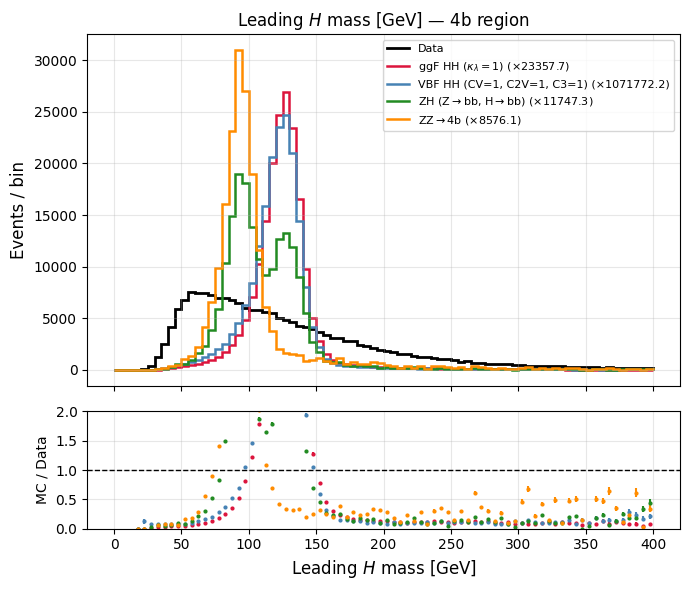

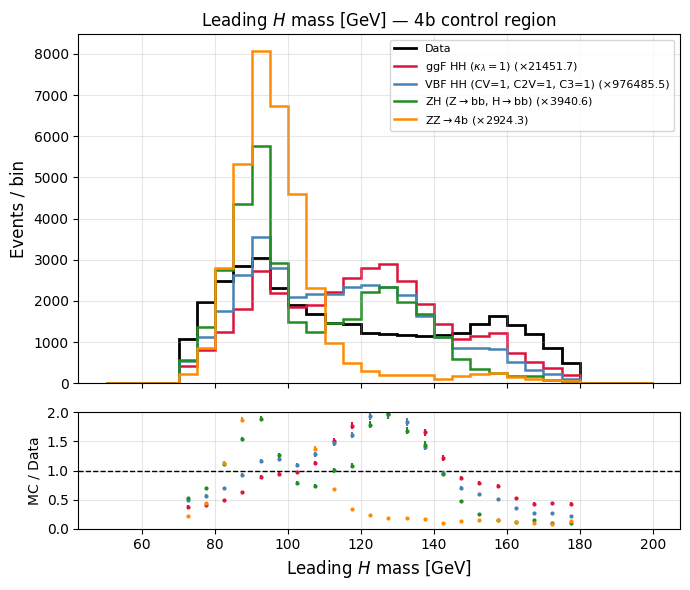

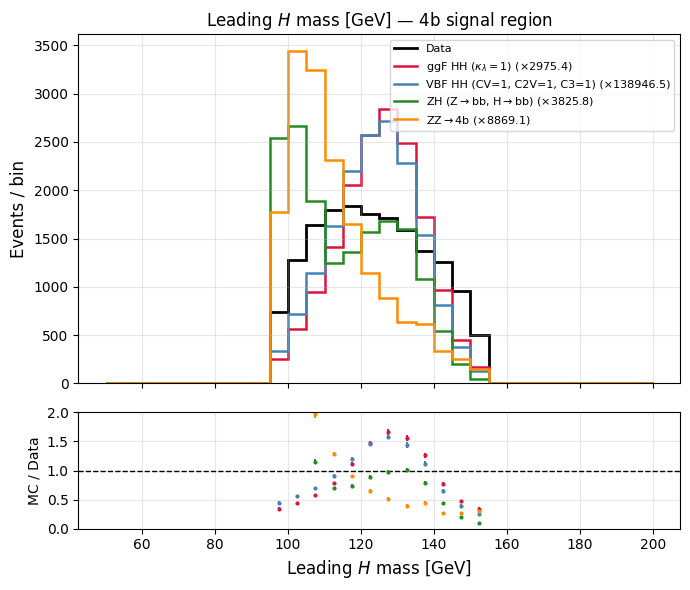

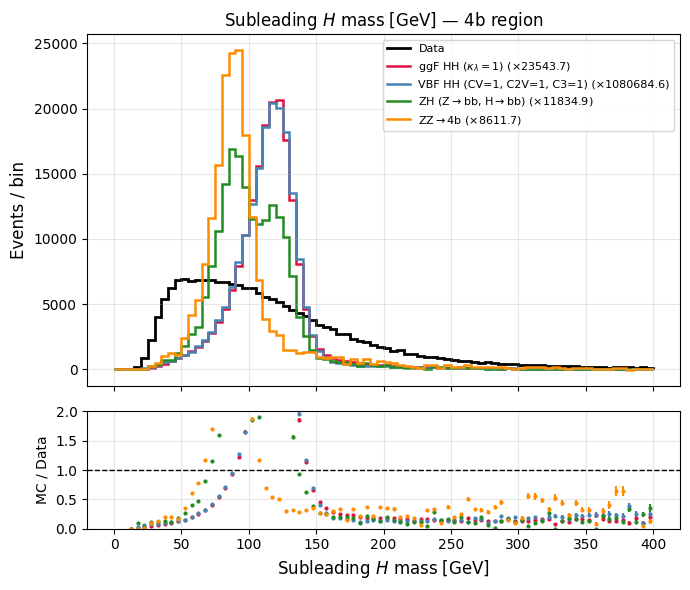

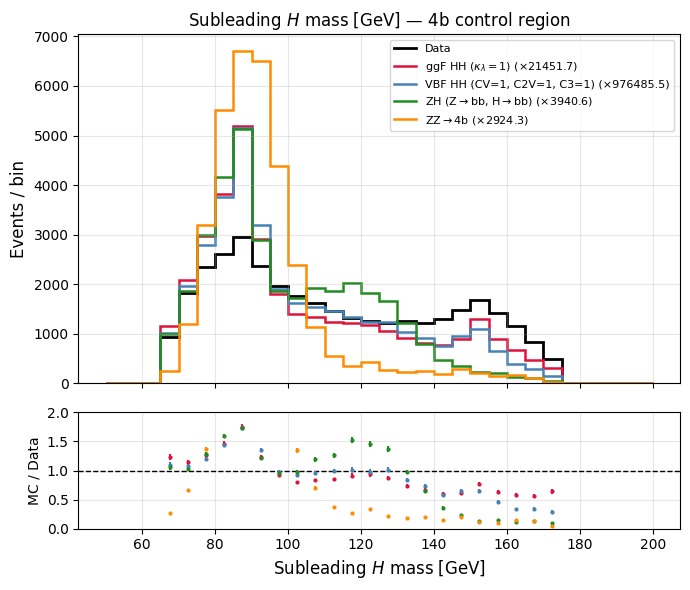

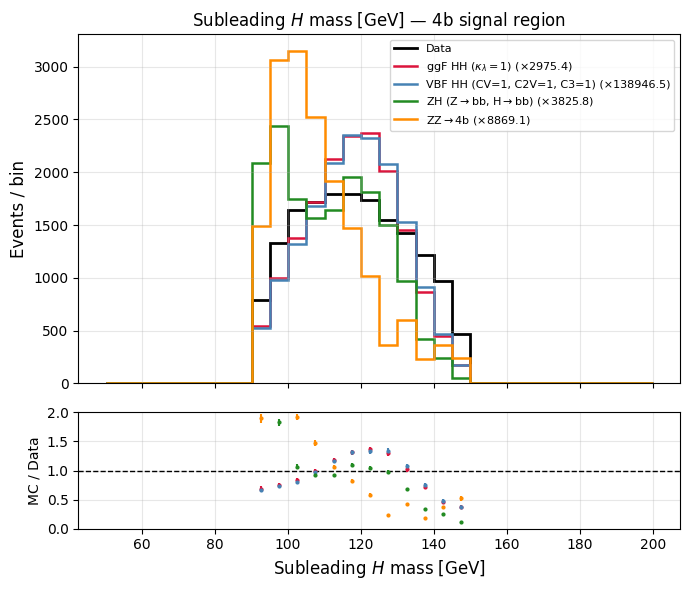

In [13]:
def _ratio_and_err(num, den):
    """Bin-wise ratio and propagated error (Poisson sqrt(h) approx)."""
    with np.errstate(divide="ignore", invalid="ignore"):
        r   = np.where(den > 0, num / den, np.nan)
        err = np.where(den > 0,
                       r * np.sqrt(1.0 / np.maximum(num, 1) + 1.0 / np.maximum(den, 1)),
                       np.nan)
    return r, err

# ── data vs MC plots — one figure per (variable × region) ─────────────────────

mc_samples_to_plot = [
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00",
    "VBFHHto4B_CV_1_C2V_1_C3_1",
    "ZH_ZToBB_HToBB",
    "ZZTo4B01j",
]

mc_labels = {
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00": r"ggF HH ($\kappa_\lambda=1$)",
    "VBFHHto4B_CV_1_C2V_1_C3_1":               r"VBF HH (CV=1, C2V=1, C3=1)",
    "ZH_ZToBB_HToBB":                           r"ZH (Z$\to$bb, H$\to$bb)",
    "ZZTo4B01j":                                r"ZZ$\to$4b",
}

mc_colors = {
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00": "crimson",
    "VBFHHto4B_CV_1_C2V_1_C3_1":               "steelblue",
    "ZH_ZToBB_HToBB":                           "forestgreen",
    "ZZTo4B01j":                                "darkorange",
}

for var, cfg in plot_configs.items():
    if var not in variables_data:
        print(f"[skip] '{var}' not found in data — skipping.")
        continue

    for region in regions:

        fig, (ax, ax_r) = plt.subplots(
            2, 1, figsize=(7, 6), sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )
        fig.subplots_adjust(hspace=0.05)

        # ── Data ──────────────────────────────────────────────────────────────
        data_col    = np.asarray(events["data"][region][var])
        data_weight = np.asarray(events["data"][region]["weight"])
        h_data, bins = np.histogram(
            data_col, bins=cfg["bins"][region], range=cfg["range"][region], weights=data_weight
        )
        centers = 0.5 * (bins[:-1] + bins[1:])

        ax.stairs(h_data, bins, color="black", label="Data", linewidth=2.0)
        ax_r.axhline(1, color="black", linewidth=1.0, linestyle="--")

        # ── MC samples ────────────────────────────────────────────────────────
        for sample in mc_samples_to_plot:
            if sample not in events["mc"]:
                continue

            mc_col_parts, mc_w_parts = [], []
            for subsample, sub_data in events["mc"][sample].items():
                if region not in sub_data:
                    continue
                mc_col_parts.append(np.asarray(sub_data[region][var]))
                mc_w_parts.append(np.asarray(sub_data[region]["weight"] / sum_gen_weights[subsample]))
            if not mc_col_parts:
                continue

            mc_col = np.concatenate(mc_col_parts)
            mc_w   = np.concatenate(mc_w_parts)
            h_mc, _ = np.histogram(mc_col, bins=bins, weights=mc_w)

            scale = h_data.sum() / h_mc.sum() if h_mc.sum() != 0 else 1.0
            h_mc_s = h_mc * scale

            ax.stairs(h_mc_s, bins, color=mc_colors[sample],
                      label=f"{mc_labels[sample]} (×{scale:.1f})", linewidth=1.8)

            ratio, ratio_err = _ratio_and_err(h_mc_s, h_data)
            ax_r.errorbar(centers, ratio, yerr=np.abs(ratio_err), fmt=".",
                          color=mc_colors[sample], markersize=4)

        ax.set_ylabel("Events / bin", fontsize=12)
        ax.set_title(f"{cfg['xlabel']} — {region.replace('_', ' ')}", fontsize=12)
        ax.legend(fontsize=8, loc="upper right")
        ax.grid(True, alpha=0.3)

        ax_r.set_xlabel(cfg["xlabel"], fontsize=12)
        ax_r.set_ylabel("MC / Data", fontsize=10)
        ax_r.set_ylim(0, 2)
        ax_r.grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()


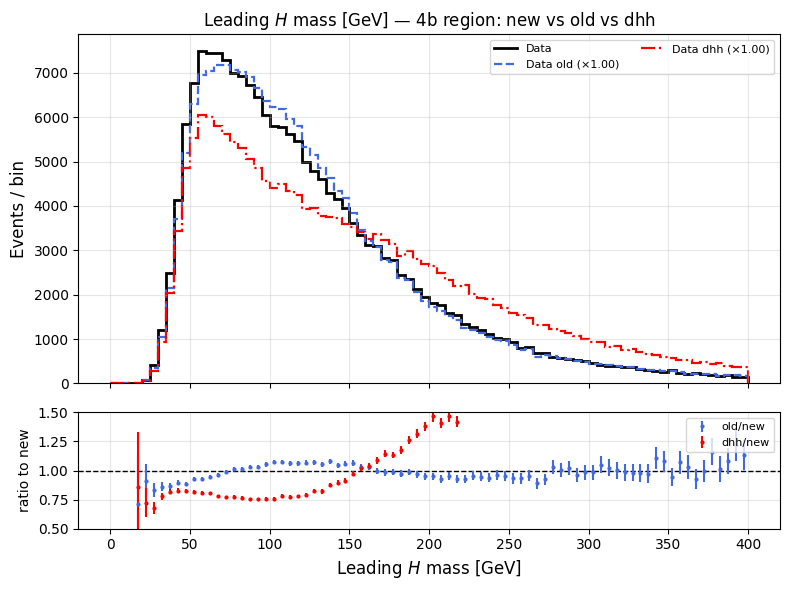

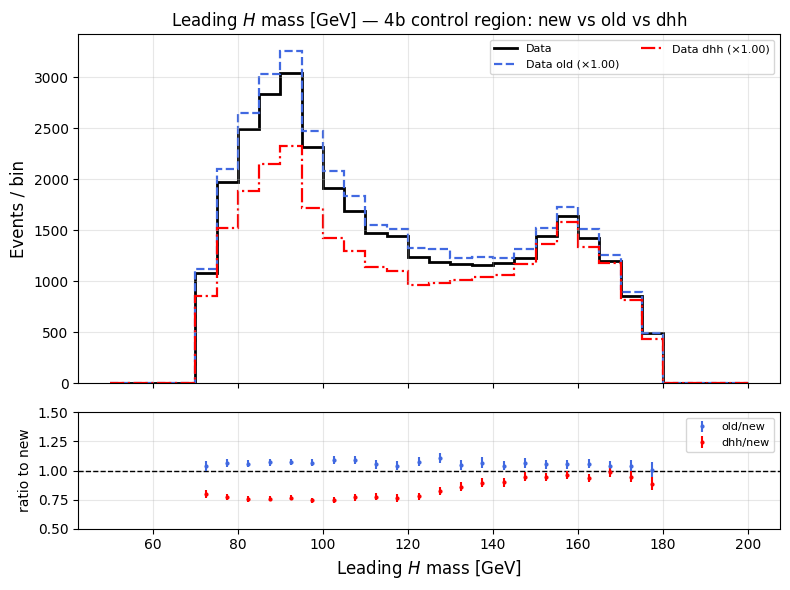

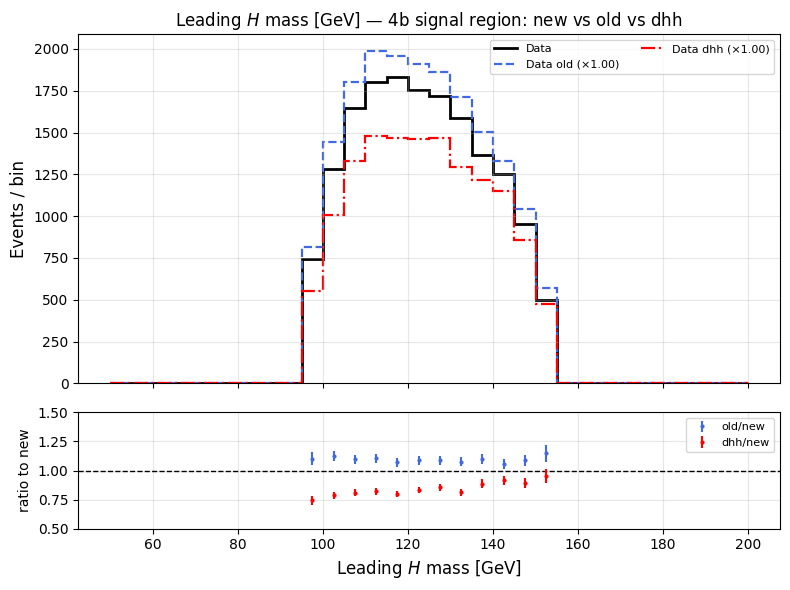

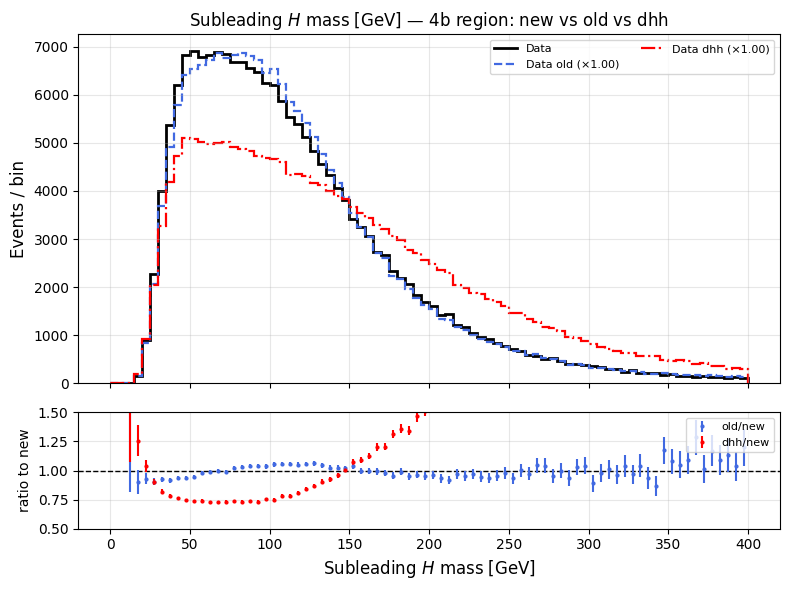

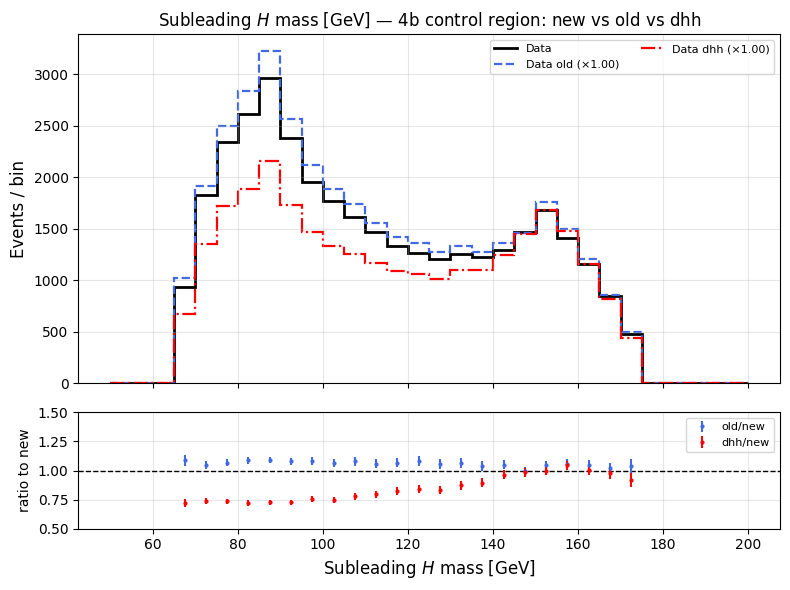

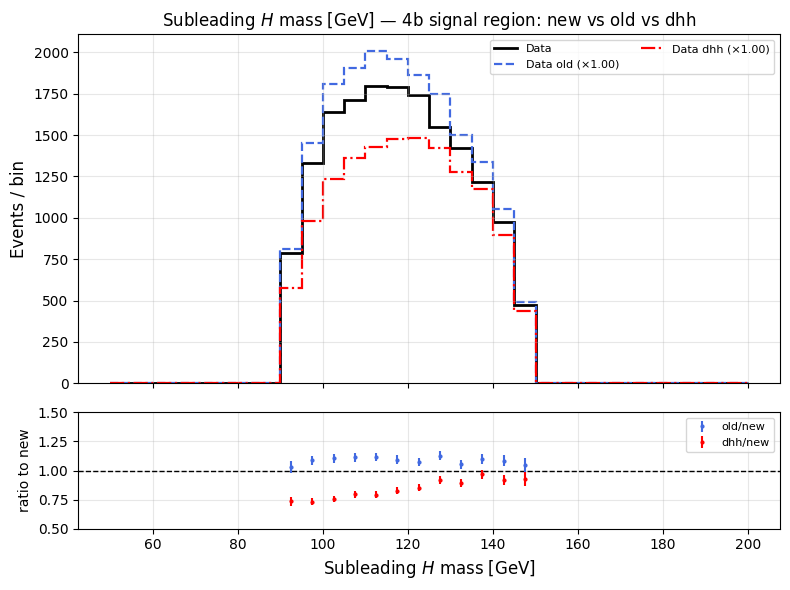

In [17]:
# ── new vs old comparison: data and MC, for compare_regions ──────────────────

compare_regions = ["4b_region", "4b_control_region", "4b_signal_region"]

mc_samples_to_plot = [
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00",
    "VBFHHto4B_CV_1_C2V_1_C3_1",
    "ZH_ZToBB_HToBB",
    "ZZTo4B01j",
]

mc_labels = {
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00": r"ggF HH ($\kappa_\lambda=1$)",
    "VBFHHto4B_CV_1_C2V_1_C3_1":               r"VBF HH (CV=1, C2V=1, C3=1)",
    "ZH_ZToBB_HToBB":                           r"ZH (Z$\to$bb, H$\to$bb)",
    "ZZTo4B01j":                                r"ZZ$\to$4b",
}

mc_colors = {
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00": "crimson",
    "VBFHHto4B_CV_1_C2V_1_C3_1":               "steelblue",
    "ZH_ZToBB_HToBB":                           "forestgreen",
    "ZZTo4B01j":                                "darkorange",
}

style = {
    "new": {"linestyle": "-",  "linewidth": 2.0},
    "old": {"linestyle": "--", "linewidth": 1.6},
    "dhh": {"linestyle": "-.", "linewidth": 1.6},
}

PLOT_MC = False

for var, cfg in plot_configs.items():
    for region in compare_regions:

        fig, (ax, ax_r) = plt.subplots(
            2, 1, figsize=(8, 6), sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )
        fig.subplots_adjust(hspace=0.05)
        centers = None

        # ── Data new (reference) ───────────────────────────────────────────────
        data_col    = np.asarray(events["data"][region][var])
        data_weight = np.asarray(events["data"][region]["weight"])
        h_data, bins = np.histogram(
            data_col, bins=cfg["bins"][region], range=cfg["range"][region], weights=data_weight
        )
        centers = 0.5 * (bins[:-1] + bins[1:])
        ax.stairs(h_data, bins, color="black", label="Data", **style["new"])
        ax_r.axhline(1, color="black", linewidth=1.0, linestyle="--")

        # ── Data old ──────────────────────────────────────────────────────────
        h_data_old, _ = np.histogram(
            np.asarray(events_old["data"][region][var]), bins=bins,
            weights=np.asarray(events_old["data"][region]["weight"])
        )
        scale_old = 1# h_data.sum() / h_data_old.sum() if h_data_old.sum() != 0 else 1.0
        h_data_old_s = h_data_old * scale_old
        ax.stairs(h_data_old_s, bins, color="royalblue",
                  label=f"Data old (×{scale_old:.2f})", **style["old"])
        r_old, re_old = _ratio_and_err(h_data_old_s, h_data)
        ax_r.errorbar(centers, r_old, yerr=re_old, fmt=".",
                      color="royalblue", markersize=4, label="old/new")

        # ── Data dhh ──────────────────────────────────────────────────────────
        h_data_dhh, _ = np.histogram(
            np.asarray(events_dhh["data"][region][var]), bins=bins,
            weights=np.asarray(events_dhh["data"][region]["weight"])
        )
        scale_dhh = 1.# h_data.sum() / h_data_dhh.sum() if h_data_dhh.sum() != 0 else 1.0
        h_data_dhh_s = h_data_dhh * scale_dhh
        ax.stairs(h_data_dhh_s, bins, color="red",
                  label=f"Data dhh (×{scale_dhh:.2f})", **style["dhh"])
        r_dhh, re_dhh = _ratio_and_err(h_data_dhh_s, h_data)
        ax_r.errorbar(centers, r_dhh, yerr=re_dhh, fmt=".",
                      color="red", markersize=4, label="dhh/new")

        if PLOT_MC:
            for sample in mc_samples_to_plot:
                color = mc_colors[sample]
                lbl   = mc_labels[sample]

                def _mch(evts, bns):
                    pc, pw = [], []
                    if sample not in evts["mc"]:
                        return None
                    for sd in evts["mc"][sample].values():
                        if region not in sd:
                            continue
                        pc.append(np.asarray(sd[region][var]))
                        pw.append(np.asarray(sd[region]["weight"]))
                    if not pc:
                        return None
                    h, _ = np.histogram(np.concatenate(pc), bins=bns,
                                        weights=np.concatenate(pw))
                    return h

                h_mc = _mch(events, bins)
                if h_mc is not None:
                    sc = h_data.sum() / h_mc.sum() if h_mc.sum() != 0 else 1.0
                    ax.stairs(h_mc * sc, bins, color=color,
                              label=f"{lbl} (×{sc:.1f})", **style["new"])

                h_mc_old = _mch(events_old, bins)
                if h_mc_old is not None and h_mc is not None:
                    sc_o = h_data.sum() / h_mc_old.sum() if h_mc_old.sum() != 0 else 1.0
                    ax.stairs(h_mc_old * sc_o, bins, color=color,
                              label=f"{lbl} old (×{sc_o:.1f})", **style["old"])
                    r, re = _ratio_and_err(h_mc_old * sc_o, h_mc * sc)
                    ax_r.errorbar(centers, r, yerr=re, fmt="s",
                                  color=color, markersize=3)

                h_mc_dhh = _mch(events_dhh, bins)
                if h_mc_dhh is not None and h_mc is not None:
                    sc_d = h_data.sum() / h_mc_dhh.sum() if h_mc_dhh.sum() != 0 else 1.0
                    ax.stairs(h_mc_dhh * sc_d, bins, color=color,
                              label=f"{lbl} dhh (×{sc_d:.1f})", **style["dhh"])
                    r, re = _ratio_and_err(h_mc_dhh * sc_d, h_mc * sc)
                    ax_r.errorbar(centers, r, yerr=re, fmt="^",
                                  color=color, markersize=3)

        ax.set_ylabel("Events / bin", fontsize=12)
        ax.set_title(
            f"{cfg['xlabel']} — {region.replace('_', ' ')}: new vs old vs dhh",
            fontsize=12,
        )
        ax.legend(fontsize=8, loc="upper right", ncol=2)
        ax.grid(True, alpha=0.3)

        ax_r.set_xlabel(cfg["xlabel"], fontsize=12)
        ax_r.set_ylabel("ratio to new", fontsize=10)
        ax_r.set_ylim(0.5, 1.5)
        ax_r.legend(fontsize=8, loc="upper right")
        ax_r.grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()


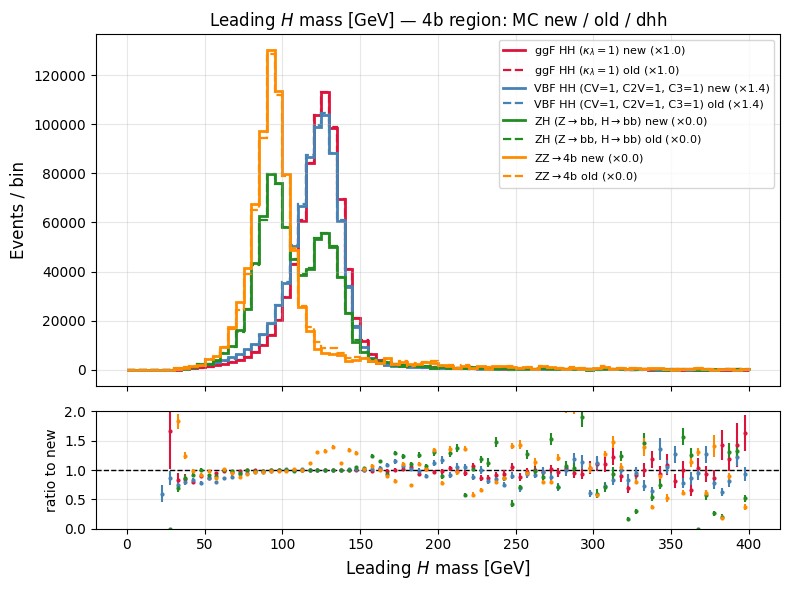

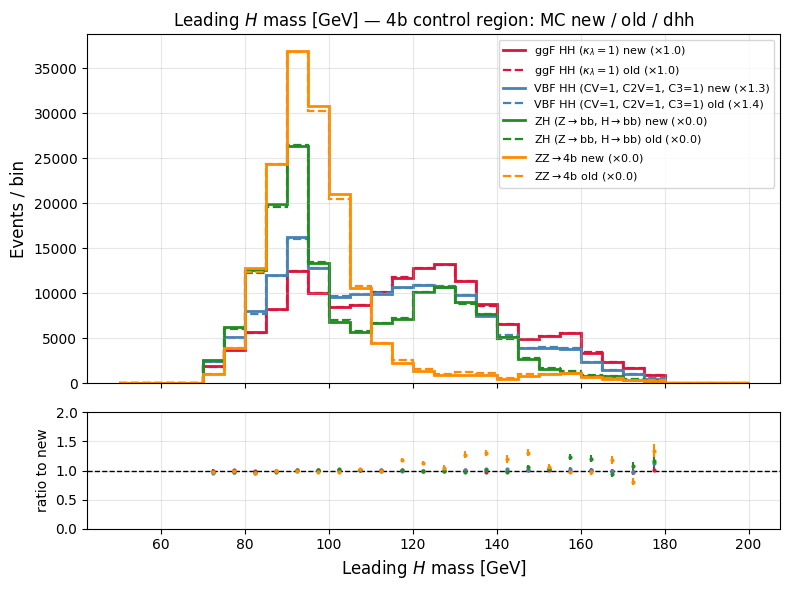

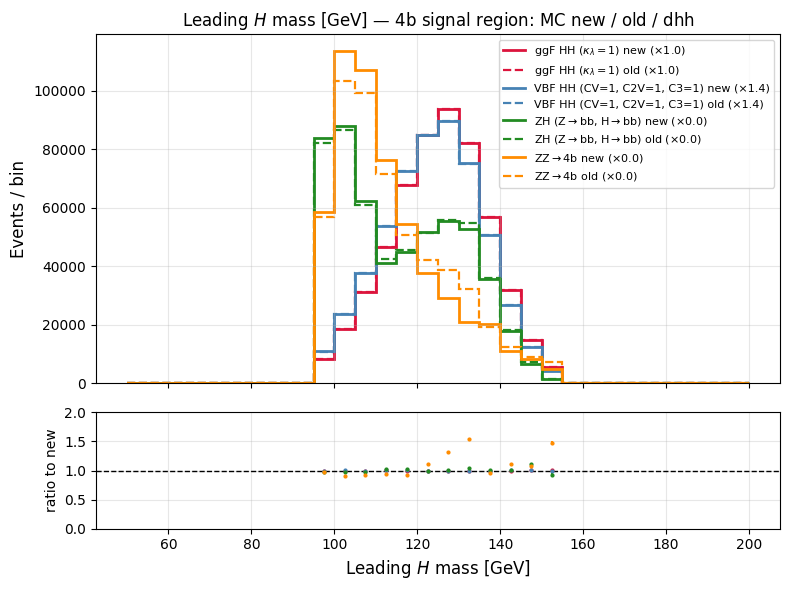

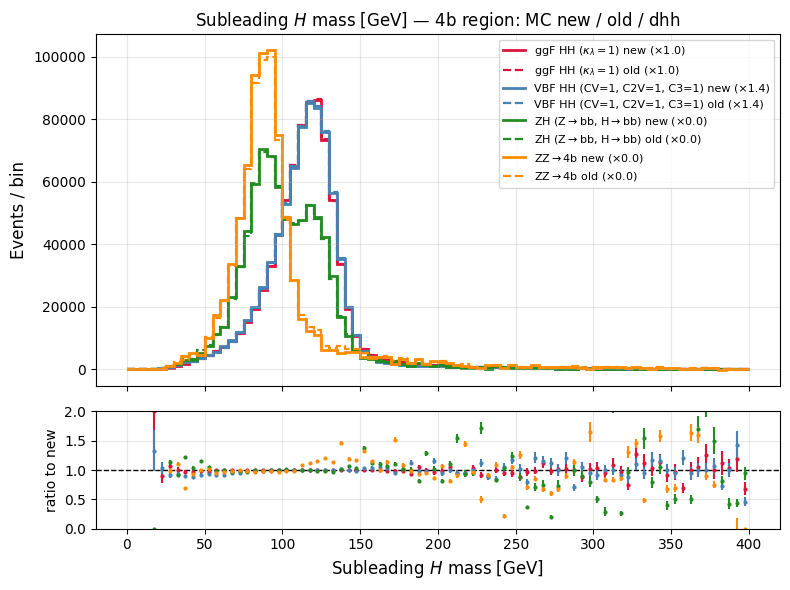

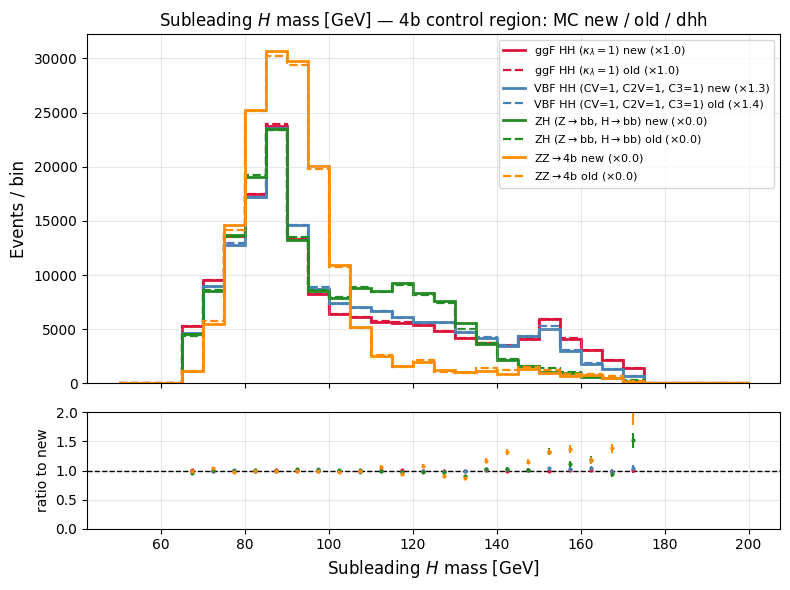

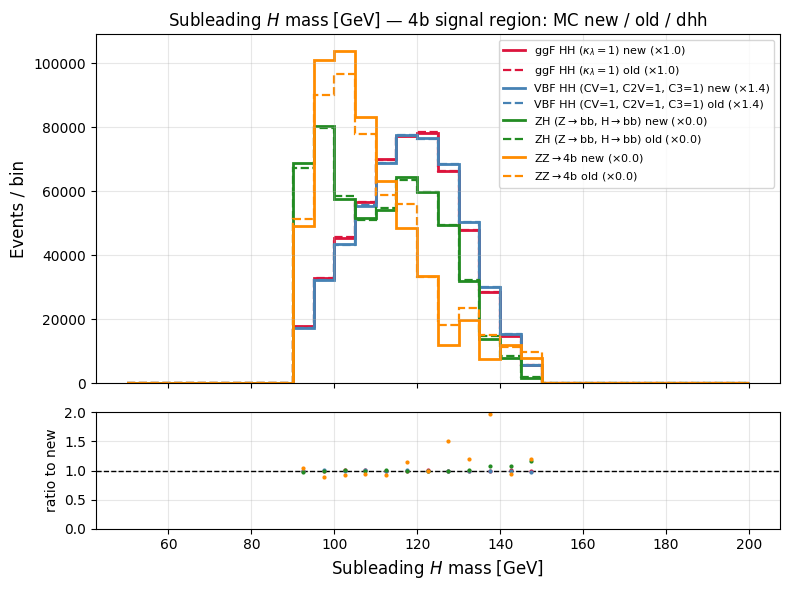

In [15]:
# ── MC new / old / dhh comparison, per variable × region ─────────────────────

def get_mc_hist(evts, bns, sample, region, var):
    """Return weighted histogram for *sample* from *evts*, or None if missing."""
    if sample not in evts["mc"]:
        return None
    parts_col, parts_w = [], []
    for sub_data in evts["mc"][sample].values():
        if region not in sub_data:
            continue
        parts_col.append(np.asarray(sub_data[region][var]))
        parts_w.append(np.asarray(sub_data[region]["weight"]))
    if not parts_col:
        return None
    h, _ = np.histogram(np.concatenate(parts_col), bins=bns,
                        weights=np.concatenate(parts_w))
    return h


mc_versions = [
    ("new", events,     style["new"]),
    ("old", events_old, style["old"]),
    ("dhh", events_dhh, style["dhh"]),
]

for var, cfg in plot_configs.items():
    for region in compare_regions:

        fig, (ax, ax_r) = plt.subplots(
            2, 1, figsize=(8, 6), sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )
        fig.subplots_adjust(hspace=0.05)

        _, bins = np.histogram([], bins=cfg["bins"][region], range=cfg["range"][region])
        centers = 0.5 * (bins[:-1] + bins[1:])

        ref_sum = None

        ax_r.axhline(1, color="black", linewidth=1.0, linestyle="--")

        for sample in mc_samples_to_plot:
            color = mc_colors[sample]
            label = mc_labels[sample]

            h_new = get_mc_hist(events, bins, sample, region, var)
            if h_new is None:
                continue

            if ref_sum is None:
                ref_sum = h_new.sum() if h_new.sum() != 0 else 1.0

            scale_new = ref_sum / h_new.sum() if h_new.sum() != 0 else 1.0
            h_new_s = h_new * scale_new
            ax.stairs(h_new_s, bins, color=color,
                      label=f"{label} new (×{scale_new:.1f})", **style["new"])

            for tag, evts_v, sty in [("old", events_old, style["old"])]: # [("old", events_old, style["old"]), ("dhh", events_dhh, style["dhh"])]:
                h_v = get_mc_hist(evts_v, bins, sample, region, var)
                if h_v is None:
                    continue
                scale_v = ref_sum / h_v.sum() if h_v.sum() != 0 else 1.0
                h_v_s = h_v * scale_v
                ax.stairs(h_v_s, bins, color=color,
                          label=f"{label} {tag} (×{scale_v:.1f})", **sty)

                ratio, ratio_err = _ratio_and_err(h_v_s, h_new_s)
                fmt = "." if tag == "old" else "^"
                ax_r.errorbar(centers, ratio, yerr=np.abs(ratio_err),
                              fmt=fmt, color=color, markersize=4,
                              label=f"{label} {tag}/new")

        ax.set_ylabel("Events / bin", fontsize=12)
        ax.set_title(
            f"{cfg['xlabel']} — {region.replace('_', ' ')}: MC new / old / dhh",
            fontsize=12,
        )
        ax.legend(fontsize=8, loc="upper right", ncol=1)
        ax.grid(True, alpha=0.3)

        ax_r.set_xlabel(cfg["xlabel"], fontsize=12)
        ax_r.set_ylabel("ratio to new", fontsize=10)
        ax_r.set_ylim(0, 2)
        ax_r.grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()


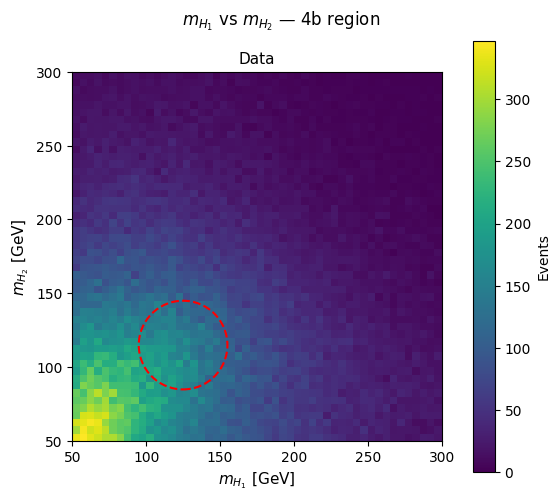

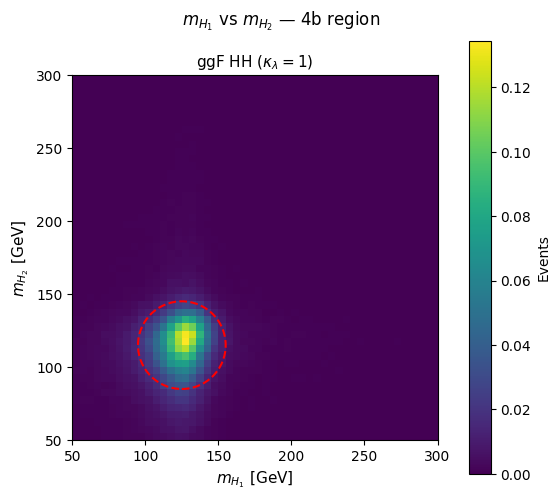

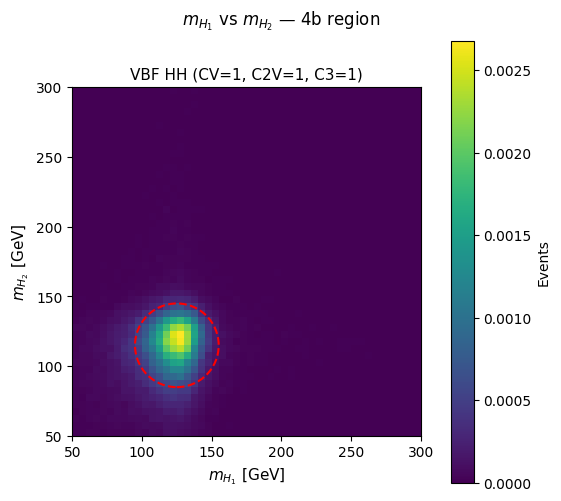

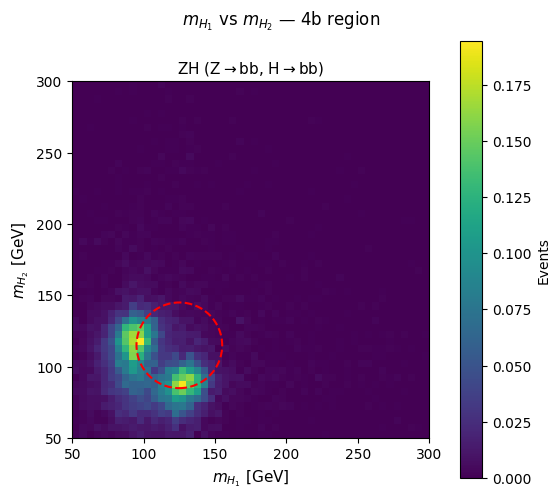

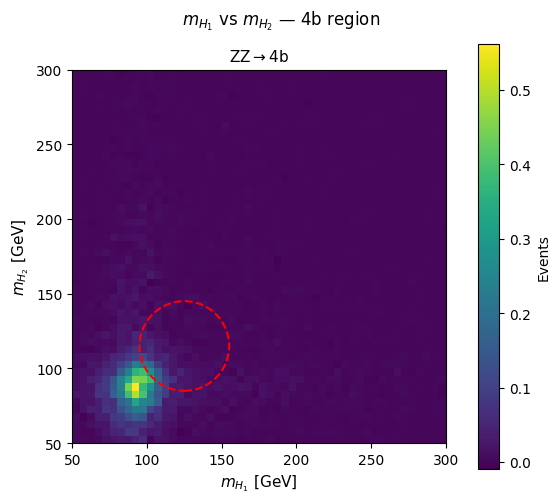

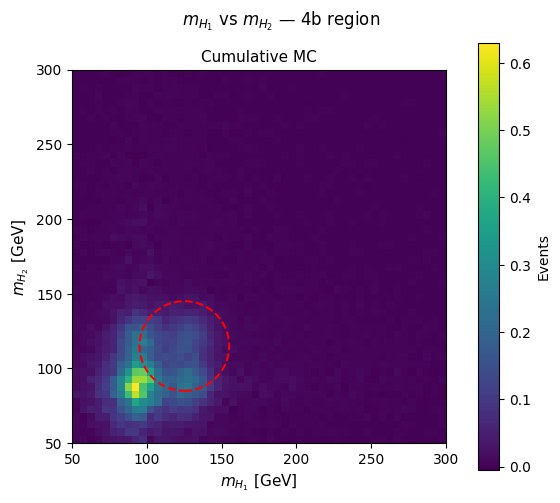

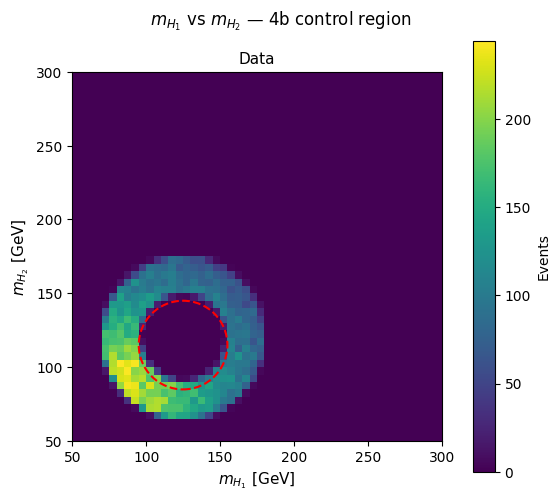

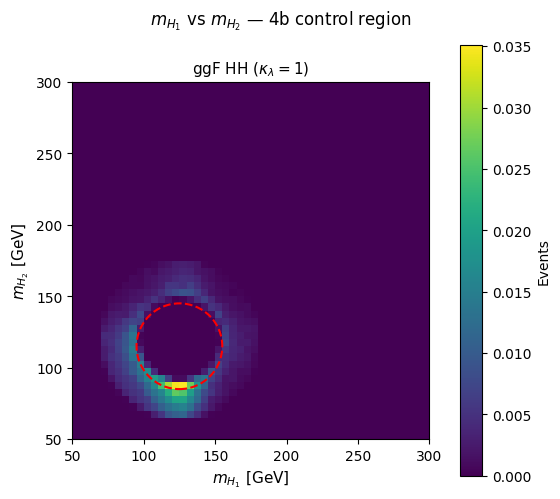

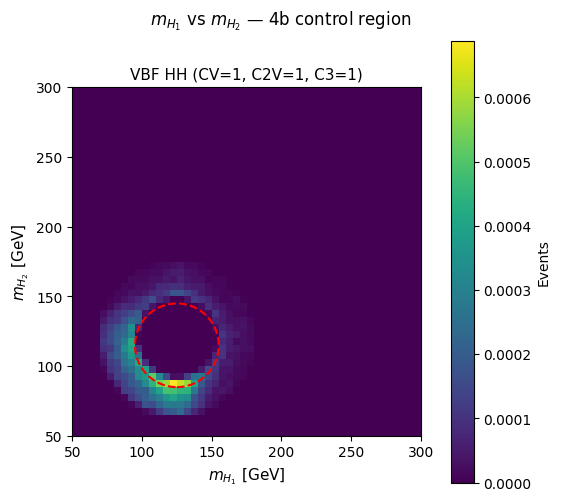

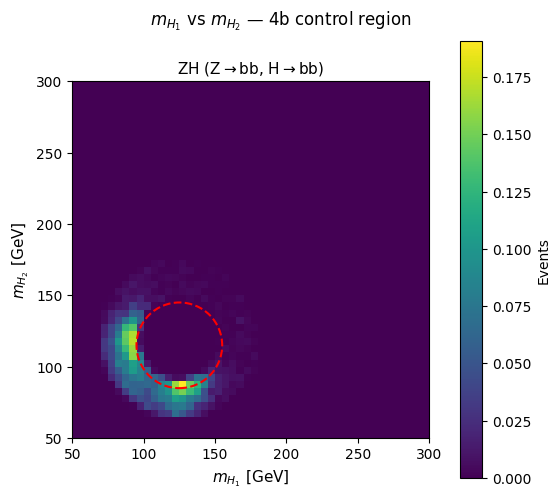

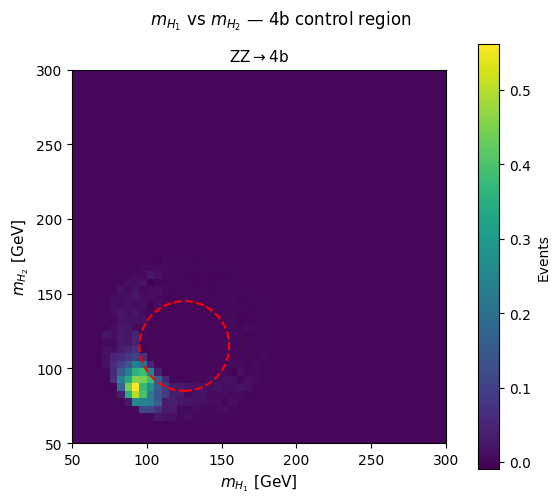

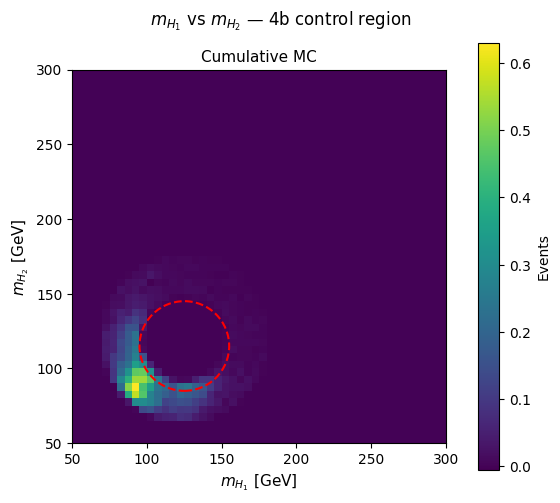

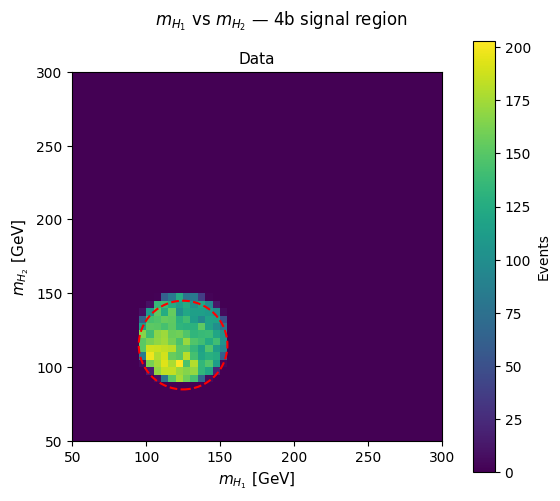

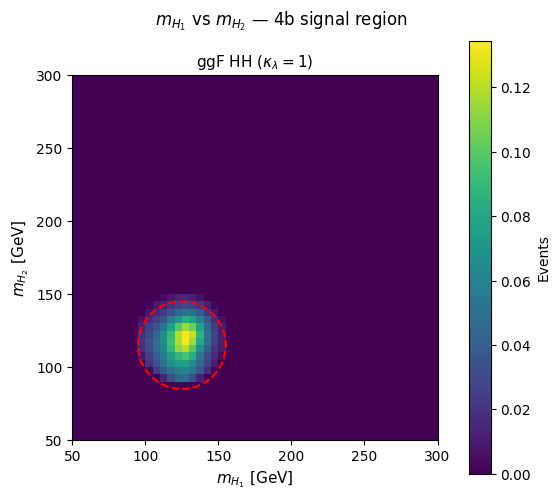

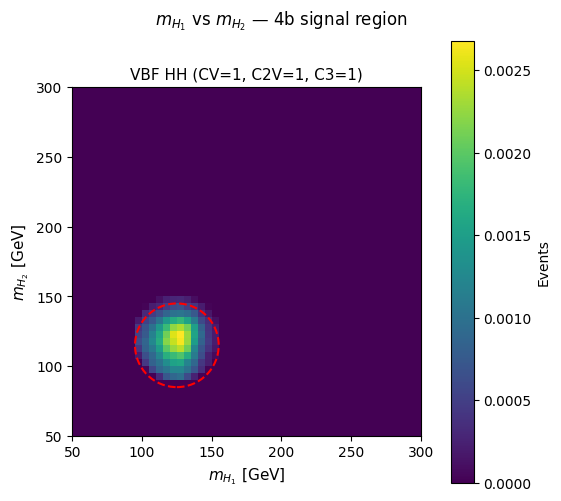

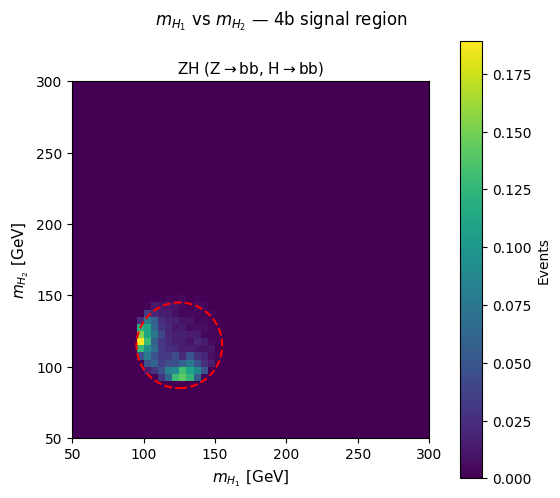

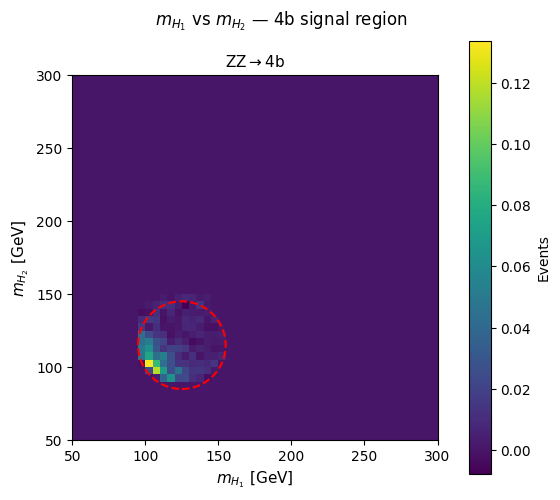

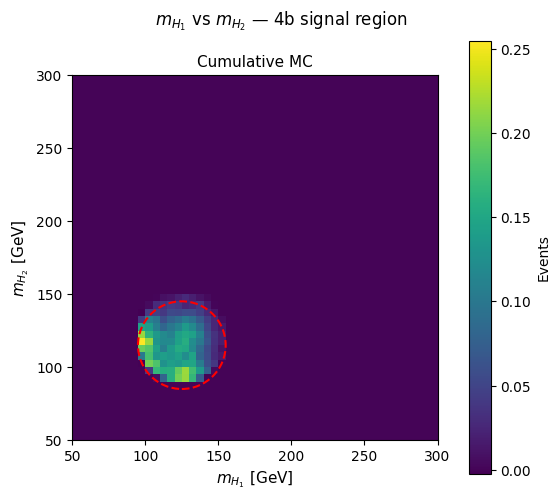

In [16]:
# ── 2D plots: H1 (leading) mass vs H2 (subleading) mass ──────────────────────
# One canvas per dataset × region; includes a cumulative MC panel.

from matplotlib.patches import Ellipse

mass_range = (50, 300)
mass_bins  = 50

mc_samples_2d = [
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00",
    "VBFHHto4B_CV_1_C2V_1_C3_1",
    "ZH_ZToBB_HToBB",
    "ZZTo4B01j",
]
mc_labels_2d = {
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00": r"ggF HH ($\kappa_\lambda=1$)",
    "VBFHHto4B_CV_1_C2V_1_C3_1":               r"VBF HH (CV=1, C2V=1, C3=1)",
    "ZH_ZToBB_HToBB":                           r"ZH (Z$\to$bb, H$\to$bb)",
    "ZZTo4B01j":                                r"ZZ$\to$4b",
}


def _get_2d_arrays(evts, region, mc_sample=None):
    """Return (h1, h2, weights) arrays for data (mc_sample=None) or a MC sample."""
    if mc_sample is None:
        h1 = np.asarray(evts["data"][region]["HiggsLeading_mass"])
        h2 = np.asarray(evts["data"][region]["HiggsSubLeading_mass"])
        w  = np.asarray(evts["data"][region]["weight"])
        return h1, h2, w

    h1_p, h2_p, w_p = [], [], []
    if mc_sample not in evts["mc"]:
        return None, None, None
    for subsample, sub_data in evts["mc"][mc_sample].items():
        if region not in sub_data:
            continue
        h1_p.append(np.asarray(sub_data[region]["HiggsLeading_mass"]))
        h2_p.append(np.asarray(sub_data[region]["HiggsSubLeading_mass"]))
        w_p.append(np.asarray(sub_data[region]["weight"] / sum_gen_weights[subsample]))
    if not h1_p:
        return None, None, None
    return np.concatenate(h1_p), np.concatenate(h2_p), np.concatenate(w_p)


def _draw_2d(ax, fig, h1, h2, w, title):
    """Fill one 2D panel."""
    h2d, xedges, yedges = np.histogram2d(
        h1, h2, bins=mass_bins,
        range=[mass_range, mass_range], weights=w,
    )
    im = ax.pcolormesh(xedges, yedges, h2d.T, cmap="viridis")
    fig.colorbar(im, ax=ax, label="Events")
    ell = Ellipse(xy=(125, 115), width=60, height=60,
                  edgecolor="red", fc="none", lw=1.5, linestyle="--")
    ax.add_patch(ell)
    ax.set_xlabel(r"$m_{H_1}$ [GeV]", fontsize=11)
    ax.set_ylabel(r"$m_{H_2}$ [GeV]", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(mass_range)
    ax.set_ylim(mass_range)
    ax.set_aspect("equal")


for region in regions:
    region_label = region.replace("_", " ")

    # ── Data ──────────────────────────────────────────────────────────────────
    h1, h2, w = _get_2d_arrays(events, region)
    fig, ax = plt.subplots(figsize=(5.5, 5), constrained_layout=True)
    fig.suptitle(f"$m_{{H_1}}$ vs $m_{{H_2}}$ — {region_label}", fontsize=12)
    _draw_2d(ax, fig, h1, h2, w, "Data")
    plt.show()

    # ── Individual MC samples ──────────────────────────────────────────────────
    for sample in mc_samples_2d:
        h1, h2, w = _get_2d_arrays(events, region, mc_sample=sample)
        if h1 is None:
            continue
        fig, ax = plt.subplots(figsize=(5.5, 5), constrained_layout=True)
        fig.suptitle(f"$m_{{H_1}}$ vs $m_{{H_2}}$ — {region_label}", fontsize=12)
        _draw_2d(ax, fig, h1, h2, w, mc_labels_2d[sample])
        plt.show()

    # ── Cumulative MC (all samples summed) ────────────────────────────────────
    h1_all, h2_all, w_all = [], [], []
    for sample in mc_samples_2d:
        h1, h2, w = _get_2d_arrays(events, region, mc_sample=sample)
        if h1 is None:
            continue
        h1_all.append(h1)
        h2_all.append(h2)
        w_all.append(w)

    if h1_all:
        fig, ax = plt.subplots(figsize=(5.5, 5), constrained_layout=True)
        fig.suptitle(f"$m_{{H_1}}$ vs $m_{{H_2}}$ — {region_label}", fontsize=12)
        _draw_2d(ax, fig,
                 np.concatenate(h1_all),
                 np.concatenate(h2_all),
                 np.concatenate(w_all),
                 "Cumulative MC")
        plt.show()
